# CISC 473 — MC Dropout ResNet-20 on CIFAR-10 + Split Conformal Prediction

Implements **MC Dropout** (Gal & Ghahramani, 2016, *"Dropout as a Bayesian
Approximation"*, https://arxiv.org/abs/1506.02142) on top of the same
`cifar10_resnet20` backbone used in the baseline notebook, trained the same
way (from scratch, cross-entropy, SGD + momentum, cosine LR, CPU-feasible).

What changes vs. the baseline:
- A single `nn.Dropout` layer is inserted **before the final fully-connected
  layer**, at `p=0.5` — this is the exact setup the paper uses for its own
  convnet experiment (dropout applied "before the last fully connected
  inner-product layer," section 5.2), and is the standard way dropout is
  already used in convnets, so no new modification is made to the
  architecture beyond adding this one layer.
- At **evaluation time only**, dropout is kept active (instead of switching
  it off, as normal `model.eval()` would) and the model performs `T`
  stochastic forward passes per input. The predictive probability is the
  **average of the T softmax outputs** (paper, eq. 6) — this Monte Carlo
  average is what "MC Dropout" refers to.
- BatchNorm is still switched to eval mode (running statistics) during
  evaluation — only the `Dropout` module is forced back into train mode for
  the MC passes. Mixing stochastic BatchNorm into this would change the
  approximation the paper describes and just adds noise unrelated to
  epistemic uncertainty.

Everything else — data loading, the 60/20/20 stratified split, training
hyperparameters, ECE/NLL definitions, and the split-conformal (APS) layer —
is identical in structure to the baseline notebook, so the two are directly
comparable cell-for-cell. No comparison step is run here, only training +
metrics for this model on its own, per your request.


In [19]:
import os
import json
import pickle
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [20]:
# ----------------------------- Config ---------------------------------------
DATA_DIR = Path("../data/cifar-10-batches-py")

SEEDS = [0]          # keep in sync with the baseline notebook for a fair split
EPOCHS = 40
BATCH_SIZE = 128
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

TRAIN_FRAC = 0.6
TEST_FRAC = 0.2
CAL_FRAC = 0.2

ALPHA = 0.1          # miscoverage rate -> target 90% coverage
ECE_BINS = 15

DROPOUT_P = 0.5       # matches the paper's convnet setup (section 5.2)
T_MC = 50             # number of stochastic forward passes at eval time;
                       # the paper notes T=10 already gives a reasonable
                       # estimate, T=1000 was only used for smooth plotting

RESULTS_PATH = Path("mc_dropout_resnet20_results.json")

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


In [21]:
# ----------------------------- Load CIFAR-10 --------------------------------
def _unpickle(path):
    with open(path, "rb") as f:
        return pickle.load(f, encoding="bytes")


def load_cifar10(data_dir: Path):
    """Pools all 5 train batches + the test batch into 60,000 images, then
    re-split 60/20/20 below — same pooling used in the baseline notebook so
    the split is reproducible/comparable across both."""
    images, labels = [], []

    for i in range(1, 6):
        batch = _unpickle(data_dir / f"data_batch_{i}")
        images.append(batch[b"data"])
        labels.extend(batch[b"labels"])

    test_batch = _unpickle(data_dir / "test_batch")
    images.append(test_batch[b"data"])
    labels.extend(test_batch[b"labels"])

    images = np.concatenate(images, axis=0)
    images = images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # NHWC, uint8
    labels = np.array(labels, dtype=np.int64)
    return images, labels


all_images, all_labels = load_cifar10(DATA_DIR)
print(f"Loaded {all_images.shape[0]} images, shape={all_images.shape[1:]}, "
      f"classes={np.unique(all_labels)}")


Loaded 60000 images, shape=(32, 32, 3), classes=[0 1 2 3 4 5 6 7 8 9]


In [22]:
# ----------------------- Stratified 60/20/20 split ---------------------------
def stratified_split(labels, fracs, seed):
    assert abs(sum(fracs) - 1.0) < 1e-6
    rng = np.random.RandomState(seed)
    split_idxs = [[] for _ in fracs]

    for c in np.unique(labels):
        c_idx = np.where(labels == c)[0]
        rng.shuffle(c_idx)
        n = len(c_idx)
        cuts = np.cumsum([int(round(n * f)) for f in fracs])
        cuts[-1] = n
        start = 0
        for i, end in enumerate(cuts):
            split_idxs[i].append(c_idx[start:end])
            start = end

    return [np.concatenate(idx) for idx in split_idxs]


train_idx, test_idx, cal_idx = stratified_split(
    all_labels, [TRAIN_FRAC, TEST_FRAC, CAL_FRAC], seed=SEEDS[0]
)
print(f"train={len(train_idx)}  test={len(test_idx)}  calibration={len(cal_idx)}")


train=36000  test=12000  calibration=12000


In [23]:
# ----------------------------- Dataset ---------------------------------------
class CIFAR10Array(Dataset):
    def __init__(self, images, labels, indices, train: bool):
        self.images = images[indices]
        self.labels = labels[indices]
        self.train = train
        self.mean = np.array(CIFAR_MEAN, dtype=np.float32).reshape(3, 1, 1)
        self.std = np.array(CIFAR_STD, dtype=np.float32).reshape(3, 1, 1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = self.images[i]

        if self.train:
            padded = np.pad(img, ((4, 4), (4, 4), (0, 0)), mode="reflect")
            top = np.random.randint(0, 9)
            left = np.random.randint(0, 9)
            img = padded[top:top + 32, left:left + 32, :]
            if np.random.rand() < 0.5:
                img = img[:, ::-1, :]

        img = img.astype(np.float32).transpose(2, 0, 1) / 255.0
        img = (img - self.mean) / self.std
        return torch.from_numpy(img.copy()), int(self.labels[i])


train_ds = CIFAR10Array(all_images, all_labels, train_idx, train=True)
test_ds = CIFAR10Array(all_images, all_labels, test_idx, train=False)
cal_ds = CIFAR10Array(all_images, all_labels, cal_idx, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)
cal_loader = DataLoader(cal_ds, batch_size=256, shuffle=False, num_workers=0)


## Model: ResNet-20 backbone + MC Dropout head

`torch.hub`'s `CifarResNet` exposes `conv1 / bn1 / relu / layer1 / layer2 /
layer3 / avgpool / fc`. We reuse every one of those layers unchanged and only
insert a `Dropout(p=DROPOUT_P)` between `avgpool` and `fc`, mirroring the
paper's "dropout before the last fully-connected layer" setup.


In [24]:
# ------------------------------- Model ----------------------------------------
class MCDropoutResNet20(nn.Module):
    def __init__(self, dropout_p=DROPOUT_P):
        super().__init__()
        # This hub repository is structured correctly and supports pretrained=False
        base = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=False)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.avgpool = base.avgpool
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = base.fc

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


def build_model():
    return MCDropoutResNet20().to(DEVICE)


def enable_mc_dropout(model):
    """Puts only the Dropout module(s) into train mode while everything else
    (BatchNorm included) stays in eval mode -- so BN uses its running stats
    and dropout still samples a fresh mask on every forward pass."""
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


model = build_model()
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")


Total parameters: 272474


Using cache found in C:\Users\edwar/.cache\torch\hub\chenyaofo_pytorch-cifar-models_master


In [25]:
# ------------------------------ Training --------------------------------------
# Standard (single-pass) training -- dropout acts as an ordinary regularizer
# here, exactly as it would in a non-Bayesian model. MC averaging only
# happens at evaluation time, in mc_dropout_predict() below.
def evaluate_loss_acc(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss_sum += F.cross_entropy(logits, y, reduction="sum").item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum / total, correct / total


def train_baseline(seed):
    set_seed(seed)
    model = build_model()
    optimizer = torch.optim.SGD(
        model.parameters(), lr=LR, momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY, nesterov=True,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    t0 = time.time()

    for epoch in range(EPOCHS):
        model.train()
        correct, total, loss_sum = 0, 0, 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

        scheduler.step()
        train_loss, train_acc = loss_sum / total, correct / total
        test_loss, test_acc = evaluate_loss_acc(model, test_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        elapsed = time.time() - t0
        print(f"[seed {seed}] epoch {epoch+1:3d}/{EPOCHS}  "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f}  "
              f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}  "
              f"elapsed={elapsed/60:.1f}min")

    return model, history


trained_models = {}
histories = {}
for seed in SEEDS:
    m, h = train_baseline(seed)
    trained_models[seed] = m
    histories[seed] = h


Using cache found in C:\Users\edwar/.cache\torch\hub\chenyaofo_pytorch-cifar-models_master


[seed 0] epoch   1/40  train_loss=1.7677 train_acc=0.3302  test_loss=1.5318 test_acc=0.4298  elapsed=0.2min
[seed 0] epoch   2/40  train_loss=1.3382 train_acc=0.5181  test_loss=1.2594 test_acc=0.5565  elapsed=0.3min
[seed 0] epoch   3/40  train_loss=1.1442 train_acc=0.5989  test_loss=1.2003 test_acc=0.5782  elapsed=0.4min
[seed 0] epoch   4/40  train_loss=1.0342 train_acc=0.6411  test_loss=1.0841 test_acc=0.6128  elapsed=0.5min
[seed 0] epoch   5/40  train_loss=0.9433 train_acc=0.6778  test_loss=1.7201 test_acc=0.4838  elapsed=0.6min
[seed 0] epoch   6/40  train_loss=0.8823 train_acc=0.7041  test_loss=0.9885 test_acc=0.6699  elapsed=0.7min
[seed 0] epoch   7/40  train_loss=0.8298 train_acc=0.7264  test_loss=1.0332 test_acc=0.6652  elapsed=0.9min
[seed 0] epoch   8/40  train_loss=0.7893 train_acc=0.7415  test_loss=1.0163 test_acc=0.6832  elapsed=1.0min
[seed 0] epoch   9/40  train_loss=0.7578 train_acc=0.7522  test_loss=0.7909 test_acc=0.7372  elapsed=1.1min
[seed 0] epoch  10/40  train

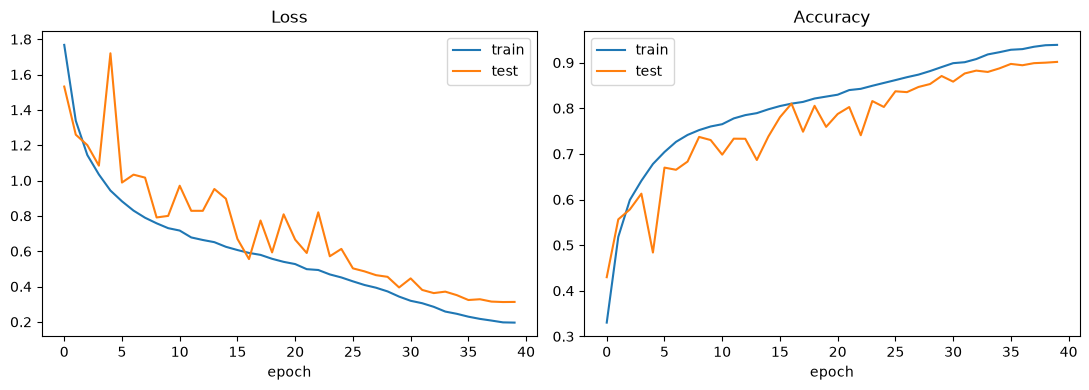

In [26]:
# ------------------------- Training curves (first seed) -----------------------
import matplotlib.pyplot as plt

h = histories[SEEDS[0]]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(h["train_loss"], label="train")
axes[0].plot(h["test_loss"], label="test")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(h["train_acc"], label="train")
axes[1].plot(h["test_acc"], label="test")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## MC Dropout calibration metrics: ECE + NLL

Unlike the baseline (a single deterministic forward pass), predictions here
are the **average of `T_MC` stochastic forward passes** with dropout active
(paper, eq. 6). ECE and NLL are then computed on that averaged distribution,
on the held-out **test** split.


In [27]:
# ------------------- MC Dropout prediction (T stochastic passes) -------------
@torch.no_grad()
def mc_dropout_predict(model, loader, T=T_MC):
    model.eval()             # BatchNorm: use running stats
    enable_mc_dropout(model)  # Dropout: keep sampling

    all_mean_probs, all_labels = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        probs_t = torch.stack(
            [F.softmax(model(x), dim=1) for _ in range(T)], dim=0
        )  # [T, B, C]
        mean_probs = probs_t.mean(dim=0)
        all_mean_probs.append(mean_probs.cpu().numpy())
        all_labels.append(y.numpy())

    return np.concatenate(all_mean_probs), np.concatenate(all_labels)


def compute_nll(probs, labels, eps=1e-12):
    p_true = probs[np.arange(len(labels)), labels]
    return float(-np.mean(np.log(np.clip(p_true, eps, 1.0))))


def compute_ece(probs, labels, n_bins=ECE_BINS):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float64)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_stats = []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (confidences > lo) & (confidences <= hi)
        prop = in_bin.mean()
        if prop > 0:
            acc_in_bin = accuracies[in_bin].mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += prop * abs(acc_in_bin - conf_in_bin)
            bin_stats.append((lo, hi, prop, acc_in_bin, conf_in_bin))

    return float(ece), bin_stats


mc_model = trained_models[SEEDS[0]]
test_probs, test_labels = mc_dropout_predict(mc_model, test_loader, T=T_MC)

mc_acc = float((test_probs.argmax(1) == test_labels).mean())
mc_nll = compute_nll(test_probs, test_labels)
mc_ece, ece_bins = compute_ece(test_probs, test_labels)

print(f"MC Dropout test accuracy : {mc_acc:.4f}")
print(f"MC Dropout NLL           : {mc_nll:.4f}")
print(f"MC Dropout ECE           : {mc_ece:.4f}")


MC Dropout test accuracy : 0.9016
MC Dropout NLL           : 0.3021
MC Dropout ECE           : 0.0151


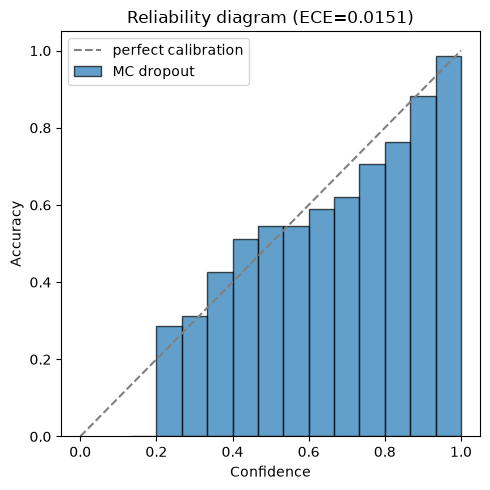

In [28]:
# Reliability diagram
confidences = test_probs.max(axis=1)
predictions = test_probs.argmax(axis=1)
accuracies = (predictions == test_labels).astype(np.float64)

bin_edges = np.linspace(0, 1, ECE_BINS + 1)
bin_centers, bin_acc = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (confidences > lo) & (confidences <= hi)
    if in_bin.sum() > 0:
        bin_centers.append((lo + hi) / 2)
        bin_acc.append(accuracies[in_bin].mean())

plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
plt.bar(bin_centers, bin_acc, width=1 / ECE_BINS, alpha=0.7, edgecolor="black", label="MC dropout")
plt.xlabel("Confidence"); plt.ylabel("Accuracy")
plt.title(f"Reliability diagram (ECE={mc_ece:.4f})")
plt.legend(); plt.tight_layout(); plt.show()


## Shared conformal calibration layer (split conformal, APS score)

Identical scheme to the baseline notebook -- it only needs softmax
probabilities, so it wraps the MC-averaged probabilities here exactly the
same way it wrapped the single-pass probabilities there. Calibrated on the
held-out `cal` split, evaluated on `test`.


In [29]:
# ------------------------- Split conformal (APS) ----------------------------
def aps_scores(probs, labels):
    order = np.argsort(-probs, axis=1)
    ranked_probs = np.take_along_axis(probs, order, axis=1)
    cumsum = np.cumsum(ranked_probs, axis=1)

    true_rank = np.array([
        np.where(order[i] == labels[i])[0][0] for i in range(len(labels))
    ])
    scores = cumsum[np.arange(len(labels)), true_rank]
    return scores


def aps_predict_sets(probs, qhat):
    order = np.argsort(-probs, axis=1)
    ranked_probs = np.take_along_axis(probs, order, axis=1)
    cumsum = np.cumsum(ranked_probs, axis=1)

    pred_sets = []
    for i in range(probs.shape[0]):
        k = np.searchsorted(cumsum[i], qhat) + 1
        k = min(k, probs.shape[1])
        pred_sets.append(set(order[i, :k].tolist()))
    return pred_sets


cal_probs, cal_labels = mc_dropout_predict(mc_model, cal_loader, T=T_MC)
cal_scores = aps_scores(cal_probs, cal_labels)

n_cal = len(cal_scores)
q_level = np.ceil((n_cal + 1) * (1 - ALPHA)) / n_cal
q_level = min(q_level, 1.0)
qhat = np.quantile(cal_scores, q_level, method="higher")

pred_sets = aps_predict_sets(test_probs, qhat)
covered = [test_labels[i] in pred_sets[i] for i in range(len(test_labels))]
set_sizes = [len(s) for s in pred_sets]

conformal_coverage = float(np.mean(covered))
conformal_avg_set_size = float(np.mean(set_sizes))

print(f"Target coverage        : {1 - ALPHA:.2f}")
print(f"qhat                    : {qhat:.4f}")
print(f"Empirical coverage      : {conformal_coverage:.4f}")
print(f"Average set size        : {conformal_avg_set_size:.2f}  (out of 10 classes)")


Target coverage        : 0.90
qhat                    : 0.9993
Empirical coverage      : 0.9999
Average set size        : 5.82  (out of 10 classes)


## Summary — MC Dropout metrics + conformal metrics

Saved to `mc_dropout_resnet20_results.json`, in the same shape as the
baseline's results file, so the two can be loaded side by side later.


In [30]:
results = {
    "model": "MC Dropout ResNet-20 (cifar10_resnet20 backbone + dropout before fc)",
    "reference": "Gal & Ghahramani 2016, https://arxiv.org/abs/1506.02142",
    "dropout_p": DROPOUT_P,
    "t_mc": T_MC,
    "seeds": SEEDS,
    "epochs": EPOCHS,
    "split": {"train": len(train_idx), "test": len(test_idx), "calibration": len(cal_idx)},
    "baseline_metrics": {
        "test_accuracy": mc_acc,
        "nll": mc_nll,
        "ece": mc_ece,
    },
    "conformal_metrics": {
        "method": "split conformal (APS)",
        "alpha": ALPHA,
        "target_coverage": 1 - ALPHA,
        "qhat": float(qhat),
        "empirical_coverage": conformal_coverage,
        "avg_set_size": conformal_avg_set_size,
    },
}

with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))


{
  "model": "MC Dropout ResNet-20 (cifar10_resnet20 backbone + dropout before fc)",
  "reference": "Gal & Ghahramani 2016, https://arxiv.org/abs/1506.02142",
  "dropout_p": 0.5,
  "t_mc": 50,
  "seeds": [
    0
  ],
  "epochs": 40,
  "split": {
    "train": 36000,
    "test": 12000,
    "calibration": 12000
  },
  "baseline_metrics": {
    "test_accuracy": 0.9015833333333333,
    "nll": 0.3020603060722351,
    "ece": 0.01511188430214924
  },
  "conformal_metrics": {
    "method": "split conformal (APS)",
    "alpha": 0.1,
    "target_coverage": 0.9,
    "qhat": 0.9993456602096558,
    "empirical_coverage": 0.9999166666666667,
    "avg_set_size": 5.819333333333334
  }
}


## Save the model

In [31]:
torch.save(mc_model.state_dict(), "../models/mc_model/mc_dropout_resnet20_seed0.pt")